In [1]:

# Upload final_data.csv when the button appears

from google.colab import files
import pandas as pd
import io

print("Please upload final_data.csv ...")
uploaded = files.upload()

filename = list(uploaded.keys())[0]
df = pd.read_csv(io.BytesIO(uploaded[filename]))

print("File loaded!")
print("Shape:", df.shape)

Please upload final_data.csv ...


Saving final_data.csv to final_data.csv
File loaded!
Shape: (22628, 12)


In [2]:

# Install and set up a mini SQL database using SQLite
# SQLite lets us run real SQL queries on our data inside Python

!pip install ipython-sql -q

import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Create an in-memory database
conn = sqlite3.connect(':memory:')

# Load our CSV data into the SQL database as a table called "reviews"
df.to_sql('reviews', conn, index=False, if_exists='replace')

print("SQL database created!")
print("Table name: reviews")
print(f"Rows loaded: {len(df)}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 20.6 MB/s eta 0:00:00
SQL database created!
Table name: reviews
Rows loaded: 22628


In [8]:

# SQL QUERY 1 — Which department has most viral products?

query1 = """
SELECT
    department_encoded                        AS department,
    COUNT(*)                                 AS total_products,
    SUM("Recommended IND")                   AS viral_count,
    ROUND(AVG("Recommended IND") * 100, 1)   AS viral_percent
FROM reviews
GROUP BY department_encoded
ORDER BY viral_percent DESC
"""

result1 = pd.read_sql_query(query1, conn)
print("QUERY 1 — Viral % By Department")
print("=" * 45)
print(result1.to_string(index=False))

QUERY 1 — Viral % By Department
 department  total_products  viral_count  viral_percent
          0            3662         3111           85.0
          2            1653         1399           84.6
          3            1002          835           83.3
          4           10048         8146           81.1
          1            6145         4948           80.5
          5             118           88           74.6


/tmp/ipykernel_8044/3444798232.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='department', y='viral_percent',


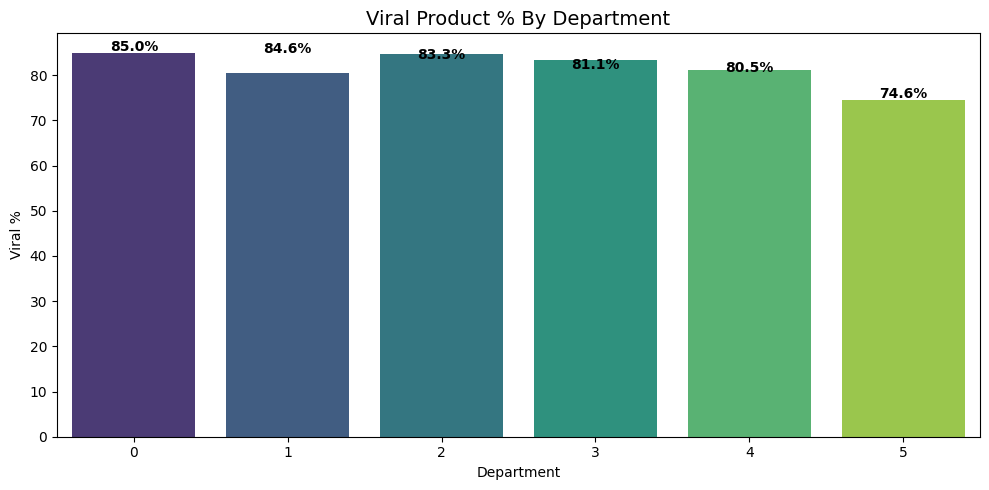

In [9]:

# Visualize Query 1 result

plt.figure(figsize=(10, 5))
sns.barplot(x='department', y='viral_percent',
            data=result1, palette='viridis')
plt.title('Viral Product % By Department', fontsize=14)
plt.xlabel('Department')
plt.ylabel('Viral %')
for i, row in result1.iterrows():
    plt.text(i, row['viral_percent'] + 0.3,
             f"{row['viral_percent']}%",
             ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

In [12]:

# SQL QUERY 2 — Does age group affect viral rate?

query2 = """
SELECT
    age_group_encoded AS age_group,
    COUNT(*)                                 AS total_reviews,
    ROUND(AVG("Recommended IND") * 100, 1)   AS viral_percent,
    ROUND(AVG(sentiment_score), 3)           AS avg_sentiment
FROM reviews
GROUP BY age_group_encoded
ORDER BY viral_percent DESC
"""

result2 = pd.read_sql_query(query2, conn)
print("QUERY 2 — Viral % By Age Group")
print("=" * 45)
print(result2.to_string(index=False))

QUERY 2 — Viral % By Age Group
 age_group  total_reviews  viral_percent  avg_sentiment
         5           2384           85.2          0.254
         1           1185           84.8          0.259
         4           6480           82.6          0.249
         3           7088           81.7          0.248
         2           5491           79.3          0.249


In [15]:

# SQL QUERY 3 — High rated + positive sentiment = always viral?

query3 = """
SELECT
    Rating,
    sentiment_encoded AS sentiment_label,
    COUNT(*)                                 AS total,
    ROUND(AVG("Recommended IND") * 100, 1)   AS viral_percent
FROM reviews
GROUP BY Rating, sentiment_encoded
ORDER BY Rating DESC, viral_percent DESC
"""

result3 = pd.read_sql_query(query3, conn)
print("QUERY 3 — Rating + Sentiment vs Viral %")
print("=" * 50)
print(result3.to_string(index=False))

QUERY 3 — Rating + Sentiment vs Viral %
 Rating  sentiment_label  total  viral_percent
      5                1  11469           99.9
      5                0   1009           99.5
      5               -1     49           98.0
      4                1   4023           97.0
      4                0    832           95.7
      4               -1     53           88.7
      3                1   1939           43.8
      3                0    783           37.9
      3               -1    101           22.8
      2                1    856            6.8
      2                0    588            5.6
      2               -1    105            2.9
      1                1    379            2.4
      1                0    325            1.8
      1               -1    117            0.0


In [18]:

# SQL QUERY 4 — Top 10 most reviewed product classes

query4 = """
SELECT
    class_encoded                            AS class_name,
    COUNT(*)                                 AS total_reviews,
    ROUND(AVG(Rating), 2)                    AS avg_rating,
    ROUND(AVG("Recommended IND") * 100, 1)   AS viral_percent
FROM reviews
GROUP BY class_encoded
ORDER BY total_reviews DESC
LIMIT 10
"""

result4 = pd.read_sql_query(query4, conn)
print("QUERY 4 — Top 10 Most Reviewed Product Classes")
print("=" * 55)
print(result4.to_string(index=False))

QUERY 4 — Top 10 Most Reviewed Product Classes
 class_name  total_reviews  avg_rating  viral_percent
          3           6145        4.14           80.5
          8           4626        4.15           81.2
          0           2983        4.14           80.7
         17           1380        4.17           79.7
         13           1350        4.26           83.3
          7           1104        4.35           88.0
          4           1059        4.24           83.3
         15            903        4.23           84.2
          6            683        4.29           84.3
         11            669        4.30           85.8


In [21]:
import numpy as np

# Create the review_length_cat column based on the median review_length
median_review_length = df['review_length'].median()
df['review_length_cat'] = np.where(
    df['review_length'] <= median_review_length, 'short', 'long'
)

# Reload the updated DataFrame into the SQL database
conn = sqlite3.connect(':memory:') # Re-create connection if not in scope, though it should be
df.to_sql('reviews', conn, index=False, if_exists='replace')

# SQL QUERY 5 — Business insight: short vs long reviews — which goes viral more?
query5 = """
SELECT
    review_length_cat                        AS review_type,
    COUNT(*)                                 AS total,
    ROUND(AVG([Recommended IND]) * 100, 1)   AS viral_percent,
    ROUND(AVG(sentiment_score), 3)           AS avg_sentiment
FROM reviews
GROUP BY review_length_cat
ORDER BY viral_percent DESC
"""

result5 = pd.read_sql_query(query5, conn)
print("QUERY 5 — Review Length vs Viral %")
print("=" * 45)
print(result5.to_string(index=False))

QUERY 5 — Review Length vs Viral %
review_type  total  viral_percent  avg_sentiment
      short  11466           82.8          0.291
       long  11162           81.0          0.208


In [22]:

# Final SQL summary — print all business insights together

print("=" * 50)
print("   TRENDLENS — SQL BUSINESS INSIGHTS")
print("=" * 50)

top_dept = result1.iloc[0]
print(f"Most viral department  : {top_dept['department']} ({top_dept['viral_percent']}%)")

top_age = result2.iloc[0]
print(f"Most viral age group   : {top_age['age_group']} ({top_age['viral_percent']}%)")

top_class = result4.iloc[0]
print(f"Most reviewed class    : {top_class['class_name']} ({top_class['total_reviews']} reviews)")

top_review = result5.iloc[0]
print(f"Reviews going viral    : {top_review['review_type']} reviews ({top_review['viral_percent']}%)")

print("=" * 50)

   TRENDLENS — SQL BUSINESS INSIGHTS
Most viral department  : 0.0 (85.0%)
Most viral age group   : 5.0 (85.2%)
Most reviewed class    : 3.0 (6145.0 reviews)
Reviews going viral    : short reviews (82.8%)
